In [1]:
print("Aku siap jadi Data Analyst 🔥")

Aku siap jadi Data Analyst 🔥


In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("Amazon_Sale_Report.csv")

In [5]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [6]:
df.shape

(128976, 21)

In [7]:
df_sample = df.head(1000)

In [8]:
df_sample.shape

(1000, 21)

In [9]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [11]:
df['Category'].value_counts()

Category
T-shirt     50292
Shirt       49877
Blazzer     15500
Trousers    10616
Perfume      1157
Wallet        926
Socks         440
Shoes         165
Watch           3
Name: count, dtype: int64

In [12]:
df.groupby('Category')['Amount'].sum()

Category
Blazzer     11215104.12
Perfume       789419.66
Shirt       21297770.08
Shoes         124752.76
Socks         150757.50
T-shirt     39206756.65
Trousers     5346286.30
Wallet        458408.18
Watch            915.00
Name: Amount, dtype: float64

In [13]:
df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
T-shirt     39206756.65
Shirt       21297770.08
Blazzer     11215104.12
Trousers     5346286.30
Perfume       789419.66
Wallet        458408.18
Socks         150757.50
Shoes         124752.76
Watch            915.00
Name: Amount, dtype: float64

In [14]:
df.isnull().sum()

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [15]:
df_clean = df.dropna(subset=['Amount'])

In [16]:
df_clean.groupby('Category')['Amount'].mean()

Category
Blazzer     762.776584
Perfume     723.574390
Shirt       455.928116
Shoes       799.697179
Socks       358.946429
T-shirt     833.317534
Trousers    526.209281
Wallet      520.327106
Watch       305.000000
Name: Amount, dtype: float64

In [17]:
df['Status'].value_counts()

Status
Shipped                          77815
Shipped - Delivered to Buyer     28756
Cancelled                        18334
Shipped - Returned to Seller      1954
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

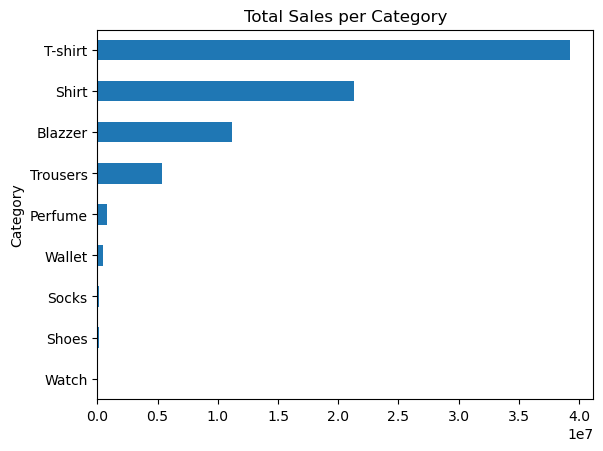

In [18]:
import matplotlib.pyplot as plt

df.groupby('Category')['Amount'].sum().sort_values().plot(kind='barh')
plt.title('Total Sales per Category')
plt.show()

In [19]:
df['Status'].str.contains('Cancelled').sum()

np.int64(18334)

In [20]:
len(df)

128976

In [21]:
df[df['Status'].str.contains('Cancelled')]['Category'].value_counts()

Category
T-shirt     7341
Shirt       7254
Blazzer     2123
Trousers    1275
Perfume      145
Wallet       116
Socks         59
Shoes         21
Name: count, dtype: int64

In [22]:
df_clean.to_csv("clean_data.csv", index=False)

In [23]:
cancel_per_cat = df[df['Status'].str.contains('Cancelled')] \
.groupby('Category')['Amount'].count().sort_values(ascending=False)

cancel_per_cat

Category
T-shirt     4202
Shirt       4190
Blazzer     1335
Trousers     829
Perfume       80
Wallet        75
Socks         40
Shoes         12
Name: Amount, dtype: int64

In [24]:
df['ship-city'].value_counts().head(10)

ship-city
BENGALURU    11208
HYDERABAD     8077
MUMBAI        6125
NEW DELHI     5792
CHENNAI       5430
PUNE          3863
KOLKATA       2380
GURUGRAM      1865
THANE         1701
LUCKNOW       1462
Name: count, dtype: int64

In [25]:
df['ship-city'].value_counts().head(10)

ship-city
BENGALURU    11208
HYDERABAD     8077
MUMBAI        6125
NEW DELHI     5792
CHENNAI       5430
PUNE          3863
KOLKATA       2380
GURUGRAM      1865
THANE         1701
LUCKNOW       1462
Name: count, dtype: int64

In [26]:
df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

ship-city
BENGALURU    6845390.65
HYDERABAD    4946394.25
MUMBAI       3701843.04
NEW DELHI    3612512.78
CHENNAI      3103415.74
PUNE         2342011.18
KOLKATA      1413603.87
GURUGRAM     1220562.74
THANE        1004503.29
LUCKNOW       938076.34
Name: Amount, dtype: float64

In [28]:
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

In [29]:
df.groupby('month')['Amount'].sum()

month
3      101683.85
4    28836200.27
5    26226476.75
6    23425809.38
Name: Amount, dtype: float64

In [30]:
df['Size'].value_counts()

Size
M       22373
L       21807
XL      20549
XXL     17806
S       16776
3XL     14643
XS      11056
Free     2251
6XL       738
5XL       550
4XL       427
Name: count, dtype: int64

In [31]:
df['Sales Channel'].value_counts()

Sales Channel
Amazon.in     128852
Non-Amazon       124
Name: count, dtype: int64

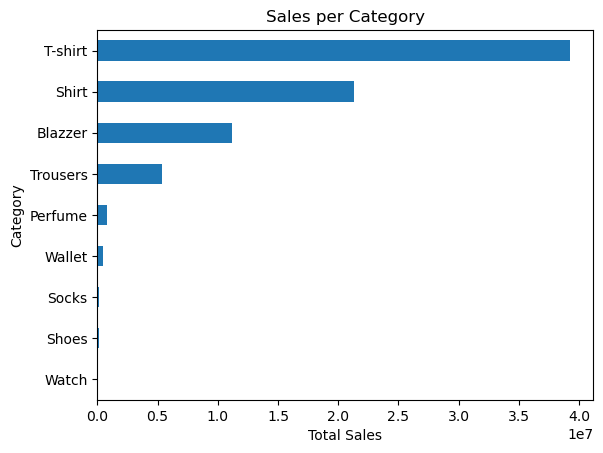

In [32]:
df.groupby('Category')['Amount'].sum().sort_values().plot(kind='barh')
plt.title('Sales per Category')
plt.xlabel('Total Sales')
plt.show()

In [33]:
df_final = df[['Category', 'Amount', 'Status', 'ship-city']]
df_final.to_csv('final_portfolio.csv', index=False)

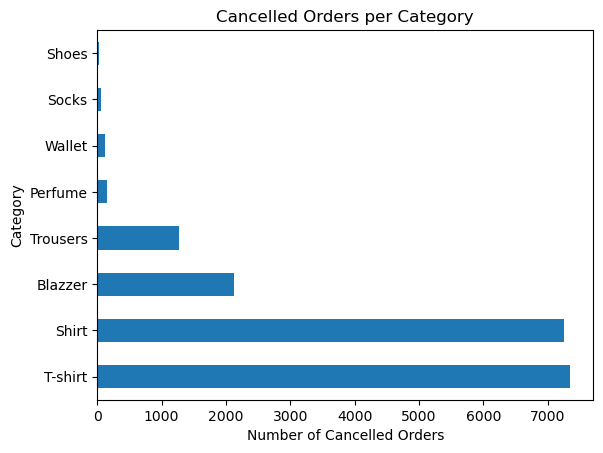

In [34]:
df[df['Status'].str.contains('Cancelled')] \
['Category'].value_counts().plot(kind='barh')

plt.title('Cancelled Orders per Category')
plt.xlabel('Number of Cancelled Orders')
plt.show()